### CONVERT LIMESEG SURFACE SEGMENTATION INTO A LABELLED MASK

In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import plyfile
import vedo
from tifffile import imread, imsave, imwrite
import matplotlib.pyplot as plt

### provide filepath to ply files and to images reporting lama signal (used to generate the LimeSeg segmentation)
path_ply = ' '
path_tif = ' ' 

print("Vedo version:", vedo.__version__)

Vedo version: 2023.5.0


In [ ]:
from PIL import Image
from PIL.TiffTags import TAGS

def get_spatial_calib_tiff(image):
    """ Gets the path/ title of a tiff file and returns the zyx pixel sizes in microns"""
    with Image.open(image) as img:
        meta_dict = {TAGS[key] : img.tag[key] for key in img.tag.keys()}

    # unit: micron
    z = [w[-4:] for w in meta_dict['ImageDescription'][0].split("\n") if w.startswith('spacing')]
    x = 1/ (meta_dict["XResolution"][0][0]/meta_dict["XResolution"][0][1])
    y = 1/ (meta_dict["YResolution"][0][0]/meta_dict["YResolution"][0][1])
   

    return float(z[0]), float("%.4f" % y), float("%.4f" % x)

#### Read the .ply files obtained from LimeSeg and the original .tif file used for the segmentation

In [ ]:
# - Read PLY files and map back onto original images ----------------------------------------------------
ply_files = sorted(glob(os.path.join(path_ply, '*.ply')))
lama_files = sorted(glob(os.path.join(path_tif, '*.tif')))

print("Found {} ply files and {} original Lama images".format(len(ply_files), len(lama_files)))

# make directory where to save the mask images
path_masks = os.path.join(path_tif, 'VolumeMasks')
os.makedirs(path_masks, exist_ok=True)

#### Function to adjust vertices from segmented surface into a numpy array
Parameters used in SkeletonSeg that you need to insert in the next cell:
+ realXYPixelSize: the size of a XY pixel in physical units (in microns)
+ Z_scale: is the physical ratio of the spacing between slices (Z spacing) and between pixels (X or Y spacing) as z/xy 

In [38]:
def convert_surface_to_volume(ply_file, pixel_coords, image_shape, z_scale):
    # read surface with vedo
    surface = vedo.load(ply_file)
    vol = surface.binarize().tonumpy()
    vol = np.transpose(vol)

    # Create empty label image with same shape as original image
    img_zeros = np.zeros(image_shape) 
    z_vol, y_vol, x_vol = np.nonzero(vol)

    # Initial coordinates to place the labeled object
    z0, y0, x0 = np.min(pixel_coords[:, 0]), np.min(pixel_coords[:, 1]), np.min(pixel_coords[:, 2]) 
   
    # Get the boundaries of the volume based on pointcloud
    x_put = x_vol + round(x0)
    y_put =  y_vol + round(y0)
    z_put = (z_vol + z0)/z_scale

    # Create volume in empy label image 
    img_zeros[z_put.astype(int), y_put, x_put ] = 255
    return img_zeros

#### Convert the surface mesh into a volume

Here, you will iterate through the list of ply files to confert the surface measurements into a numpy array, where the volume of the segmented eye is equl to 255. In case the segmentation performed using LimeSeg was not optimal, as shown in this example, you can manually curate it using the label tools in Napari. 


Processing file 1 of 1: 
 - ply file name is T_1.ply
 - image name is: C1-20230914_42-48hpf_mo42_mo22_fish03_G1_DualSideFusion
 Image shape  (203, 1920, 1920)
 Voxel size  (0.63, 0.0953, 0.0953)
4724


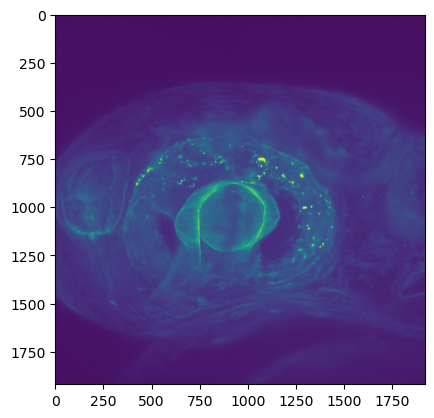

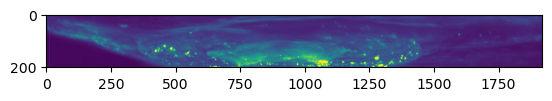

Length of vertices 7100


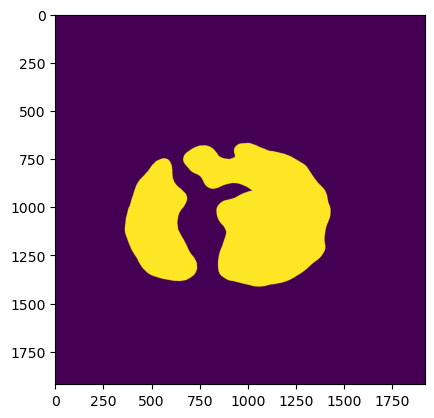

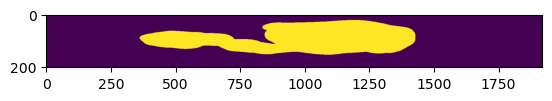

In [39]:
z_scale = 2.89
masks = []
for i in range( len(ply_files)):
    filename =  os.path.basename(lama_files[i][:-4])
    n =  len(ply_files)
    print("\nProcessing file {} of {}: \n - ply file name is {}\n - image name is: {}".format(i+1, n, 
                                                                                           os.path.basename(ply_files[i]),
                                                                                            filename))
    ### Read image reporting lama signal
    image = imread(lama_files[i])
    image_shape = image.shape
    voxel_size = get_spatial_calib_tiff(lama_files[i])
    print(" Image shape ", image_shape)
    print(" Voxel size ", voxel_size)
    print(np.max(image))
    plt.imshow(np.max(image, axis=0), vmax=1000)
    plt.show()
    plt.imshow(np.max(image, axis=1), vmax=1000)
    plt.show()

    
    ### Read ply files
    plydata = plyfile.PlyData.read(ply_files[i])

    ### Extract the vertex data
    vertices = plydata['vertex']
    print("Length of vertices", len(vertices))

    ### Extract the coordinates of points
    x = vertices['x']
    y = vertices['y']
    z = vertices['z']
    vertices = np.column_stack((z, y, x))
    
    ### Rescale pointcloud
    scaling = [1/z_scale, 1, 1]
    pixel_coords = (vertices *  np.array(scaling)).astype(int)
    
    label_image = convert_surface_to_volume(ply_files[i], pixel_coords, image_shape, z_scale)

    plt.imshow(np.max(label_image, axis=0), vmax=254)
    plt.show()

    plt.imshow(np.max(label_image, axis=1), vmax=254)
    plt.show()
    
    masks.append(np.asarray(label_image).astype(np.uint8))
    
    imwrite(os.path.join(path_masks, filename+'.tif'), 
            np.asarray(img_zeros).astype(np.uint8), imagej=True,
                resolution=(1/voxel_size[2], 1/voxel_size[1]),
                metadata={'spacing': voxel_size[0], 'unit': 'um', 'axes': 'ZYX'})
    

